In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split

iris_df = pd.read_csv('/content/iris.csv')

X = iris_df.drop('species', axis=1)
y = iris_df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

accuracy_scores = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)

optimal_k_iris = accuracy_scores.index(max(accuracy_scores)) + 1
max_accuracy_iris = max(accuracy_scores)

print(f"Optimal k for Iris dataset: {optimal_k_iris}")
print(f"Maximum accuracy with optimal k: {max_accuracy_iris:.4f}")

Optimal k for Iris dataset: 3
Maximum accuracy with optimal k: 1.0000


In [21]:
from sklearn.metrics import confusion_matrix, classification_report

knn_optimal_iris = KNeighborsClassifier(n_neighbors=optimal_k_iris)

knn_optimal_iris.fit(X_train, y_train)

y_pred_optimal_iris = knn_optimal_iris.predict(X_test)

accuracy_optimal_iris = accuracy_score(y_test, y_pred_optimal_iris)

conf_matrix_optimal_iris = confusion_matrix(y_test, y_pred_optimal_iris)

class_report_optimal_iris = classification_report(y_test, y_pred_optimal_iris)

print(f"\n--- Evaluation for Iris Dataset (Optimal k={optimal_k_iris}) ---")
print(f"Accuracy: {accuracy_optimal_iris:.4f}")
print("\nConfusion Matrix:\n", conf_matrix_optimal_iris)
print("\nClassification Report:\n", class_report_optimal_iris)


--- Evaluation for Iris Dataset (Optimal k=3) ---
Accuracy: 1.0000

Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split

diabetes_df = pd.read_csv('/content/diabetes.csv')

X_diabetes = diabetes_df.drop('Outcome', axis=1)
y_diabetes = diabetes_df['Outcome']

X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(X_diabetes, y_diabetes, test_size=0.2, stratify=y_diabetes, random_state=42)

print(f"X_train_diabetes shape: {X_train_diabetes.shape}")
print(f"X_test_diabetes shape: {X_test_diabetes.shape}")
print(f"y_train_diabetes shape: {y_train_diabetes.shape}")
print(f"y_test_diabetes shape: {y_test_diabetes.shape}")

X_train_diabetes shape: (614, 8)
X_test_diabetes shape: (154, 8)
y_train_diabetes shape: (614,)
y_test_diabetes shape: (154,)


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled_diabetes = scaler.fit_transform(X_train_diabetes)
X_test_scaled_diabetes = scaler.transform(X_test_diabetes)

print(f"X_train_scaled_diabetes shape: {X_train_scaled_diabetes.shape}")
print(f"X_test_scaled_diabetes shape: {X_test_scaled_diabetes.shape}")
print(f"First 5 rows of X_train_scaled_diabetes:\n{X_train_scaled_diabetes[:5]}")

X_train_scaled_diabetes shape: (614, 8)
X_test_scaled_diabetes shape: (154, 8)
First 5 rows of X_train_scaled_diabetes:
[[-0.85135507 -0.98013068 -0.40478372 -0.55397256 -0.33131928 -0.60767846
   0.31079384 -0.79216928]
 [ 0.35657564  0.16144422  0.46536842  0.392787   -0.52639809 -0.30213902
  -0.11643851  0.56103382]
 [-0.5493724  -0.50447447 -0.62232176  1.21331196  0.14244354  0.3725939
  -0.76486207 -0.70759409]
 [-0.85135507  0.7956525  -0.73109078 -1.31138021 -0.73076636 -0.28940821
   0.26231357 -0.36929331]
 [-1.15333775 -0.82157861 -0.29601471  1.15019465  0.24462767  1.60748245
  -0.33762972 -0.96131967]]


In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

accuracy_scores_diabetes = []

for k in range(1, 21):
    knn_diabetes = KNeighborsClassifier(n_neighbors=k)

    knn_diabetes.fit(X_train_scaled_diabetes, y_train_diabetes)

    y_pred_diabetes = knn_diabetes.predict(X_test_scaled_diabetes)

    accuracy_diabetes = accuracy_score(y_test_diabetes, y_pred_diabetes)
    accuracy_scores_diabetes.append(accuracy_diabetes)

optimal_k_diabetes = accuracy_scores_diabetes.index(max(accuracy_scores_diabetes)) + 1
max_accuracy_diabetes = max(accuracy_scores_diabetes)

print(f"Optimal k for Diabetes dataset: {optimal_k_diabetes}")
print(f"Maximum accuracy with optimal k for Diabetes dataset: {max_accuracy_diabetes:.4f}")

Optimal k for Diabetes dataset: 12
Maximum accuracy with optimal k for Diabetes dataset: 0.7727


In [25]:
from sklearn.metrics import confusion_matrix, classification_report

knn_optimal_diabetes = KNeighborsClassifier(n_neighbors=optimal_k_diabetes)

knn_optimal_diabetes.fit(X_train_scaled_diabetes, y_train_diabetes)

y_pred_optimal_diabetes = knn_optimal_diabetes.predict(X_test_scaled_diabetes)

accuracy_optimal_diabetes = accuracy_score(y_test_diabetes, y_pred_optimal_diabetes)

conf_matrix_optimal_diabetes = confusion_matrix(y_test_diabetes, y_pred_optimal_diabetes)

class_report_optimal_diabetes = classification_report(y_test_diabetes, y_pred_optimal_diabetes)

print(f"\n--- Evaluation for Diabetes Dataset (Optimal k={optimal_k_diabetes}) ---")
print(f"Accuracy: {accuracy_optimal_diabetes:.4f}")
print("\nConfusion Matrix:\n", conf_matrix_optimal_diabetes)
print("\nClassification Report:\n", class_report_optimal_diabetes)


--- Evaluation for Diabetes Dataset (Optimal k=12) ---
Accuracy: 0.7727

Confusion Matrix:
 [[88 12]
 [23 31]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.88      0.83       100
           1       0.72      0.57      0.64        54

    accuracy                           0.77       154
   macro avg       0.76      0.73      0.74       154
weighted avg       0.77      0.77      0.77       154



In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split

heart_df = pd.read_csv('/content/heart.csv')

X_heart = heart_df.drop('target', axis=1)
y_heart = heart_df['target']

X_train_heart, X_test_heart, y_train_heart, y_test_heart = train_test_split(X_heart, y_heart, test_size=0.2, stratify=y_heart, random_state=42)

print(f"X_train_heart shape: {X_train_heart.shape}")
print(f"X_test_heart shape: {X_test_heart.shape}")
print(f"y_train_heart shape: {y_train_heart.shape}")
print(f"y_test_heart shape: {y_test_heart.shape}")

X_train_heart shape: (242, 13)
X_test_heart shape: (61, 13)
y_train_heart shape: (242,)
y_test_heart shape: (61,)


In [27]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

accuracy_scores_heart = []

for k in range(1, 21):
    knn_heart = KNeighborsClassifier(n_neighbors=k)

    knn_heart.fit(X_train_heart, y_train_heart)

    y_pred_heart = knn_heart.predict(X_test_heart)

    accuracy_heart = accuracy_score(y_test_heart, y_pred_heart)
    accuracy_scores_heart.append(accuracy_heart)

optimal_k_heart = accuracy_scores_heart.index(max(accuracy_scores_heart)) + 1
max_accuracy_heart = max(accuracy_scores_heart)

print(f"Optimal k for Heart dataset: {optimal_k_heart}")
print(f"Maximum accuracy with optimal k for Heart dataset: {max_accuracy_heart:.4f}")

Optimal k for Heart dataset: 16
Maximum accuracy with optimal k for Heart dataset: 0.6721


In [28]:
from sklearn.metrics import confusion_matrix, classification_report

knn_optimal_heart = KNeighborsClassifier(n_neighbors=optimal_k_heart)

knn_optimal_heart.fit(X_train_heart, y_train_heart)

y_pred_optimal_heart = knn_optimal_heart.predict(X_test_heart)

accuracy_optimal_heart = accuracy_score(y_test_heart, y_pred_optimal_heart)

conf_matrix_optimal_heart = confusion_matrix(y_test_heart, y_pred_optimal_heart)

class_report_optimal_heart = classification_report(y_test_heart, y_pred_optimal_heart)

print(f"\n--- Evaluation for Heart Dataset (Optimal k={optimal_k_heart}) ---")
print(f"Accuracy: {accuracy_optimal_heart:.4f}")
print("\nConfusion Matrix:\n", conf_matrix_optimal_heart)
print("\nClassification Report:\n", class_report_optimal_heart)


--- Evaluation for Heart Dataset (Optimal k=16) ---
Accuracy: 0.6721

Confusion Matrix:
 [[17 11]
 [ 9 24]]

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.61      0.63        28
           1       0.69      0.73      0.71        33

    accuracy                           0.67        61
   macro avg       0.67      0.67      0.67        61
weighted avg       0.67      0.67      0.67        61



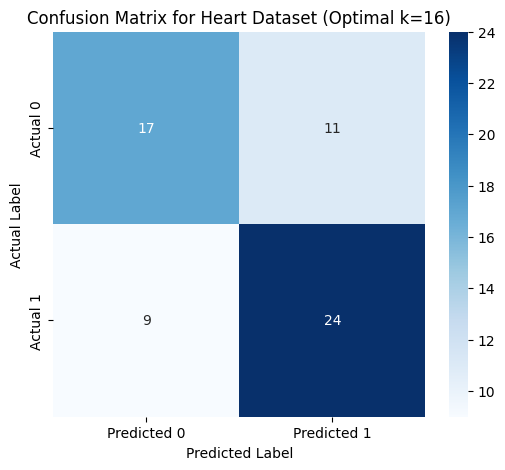

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_optimal_heart, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title(f'Confusion Matrix for Heart Dataset (Optimal k={optimal_k_heart})')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

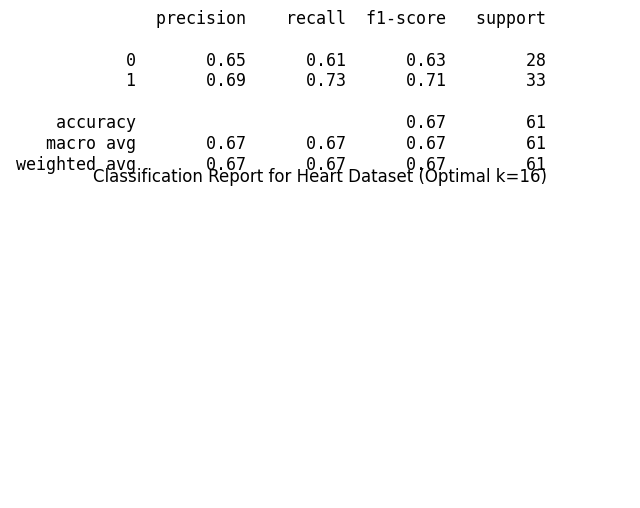

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.text(0.01, 1.0, str(class_report_optimal_heart), {'fontsize': 12}, fontproperties = 'monospace')
plt.axis('off')
plt.title(f'Classification Report for Heart Dataset (Optimal k={optimal_k_heart})')
plt.show()